In [2]:
import duckdb
import os
import pandas as pd
from utils import (
    get_df,
    compare_dataframes,
    write_parquet
)
from summarize_utils import time_query, setup_duckdb_views, plot_results

original_path = "./datasets_parquet/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"
compressed_path = "./datasets_compress/nhagar/fineweb_urls/nhagar_fineweb_urls-2.parquet"
original_size = os.path.getsize(original_path)
compressed_size = os.path.getsize(compressed_path)
con = duckdb.connect()

In [3]:
# Query timings
setup_duckdb_views(con, original_path, compressed_path)

In [4]:
t1 = time_query(con, "SUMMARIZE SELECT url FROM original")
t2 = time_query(con, "SUMMARIZE SELECT url_prefix || CASE WHEN is_outlier THEN LEFT(domain, LENGTH(domain) - 1) ELSE domain END || url_suffix AS url FROM virtual")
print(f"Original query time: {t1:.4f} seconds")
print(f"Compressed query time: {t2:.4f} seconds")

  column_name column_type                                                min  \
0         url     VARCHAR  http://0-blogs.biomedcentral.com.brum.beds.ac....   

                                                 max  approx_unique   avg  \
0  https://zzzzteng.wordpress.com/2017/01/15/job-...        1226510  <NA>   

    std   q25   q50   q75    count  null_percentage  
0  <NA>  <NA>  <NA>  <NA>  1000000              0.0  
  column_name column_type                                                min  \
0         url     VARCHAR  http://0-blogs.biomedcentral.com.brum.beds.ac....   

                                                 max  approx_unique   avg  \
0  https://zzzzteng.wordpress.com/2017/01/15/job-...        1226510  <NA>   

    std   q25   q50   q75    count  null_percentage  
0  <NA>  <NA>  <NA>  <NA>  1000000              0.0  
Original query time: 0.2506 seconds
Compressed query time: 0.3728 seconds


In [5]:
t3 = time_query(con, "SUMMARIZE SELECT LENGTH(url) FROM original")
t4 = time_query(con, "SUMMARIZE SELECT LENGTH(url_prefix || CASE WHEN is_outlier THEN LEFT(domain, LENGTH(domain) - 1) ELSE domain END || url_suffix) AS 'length(url)' FROM virtual")
t5 = time_query(con, "SUMMARIZE SELECT LENGTH(url_prefix) + CASE WHEN is_outlier THEN LENGTH(domain) - 1 ELSE LENGTH(domain) END + LENGTH(url_suffix) AS 'length(url)' FROM virtual")
print(f"Original query time: {t3:.4f} seconds")
print(f"Compressed query time: {t4:.4f} seconds")
print(f"Trick query time: {t5:.4f} seconds")

   column_name column_type min   max  approx_unique        avg  \
0  length(url)      BIGINT  14  1572            482  72.011063   

                  std q25 q50 q75    count  null_percentage  
0  27.689505978236067  52  68  87  1000000              0.0  
   column_name column_type min   max  approx_unique        avg  \
0  length(url)      BIGINT  14  1572            482  72.011063   

                  std q25 q50 q75    count  null_percentage  
0  27.689505978236067  52  68  87  1000000              0.0  


   column_name column_type min   max  approx_unique        avg  \
0  length(url)      BIGINT  14  1572            482  72.011063   

                  std q25 q50 q75    count  null_percentage  
0  27.689505978236067  52  68  87  1000000              0.0  
Original query time: 0.4594 seconds
Compressed query time: 0.5672 seconds
Trick query time: 0.5215 seconds


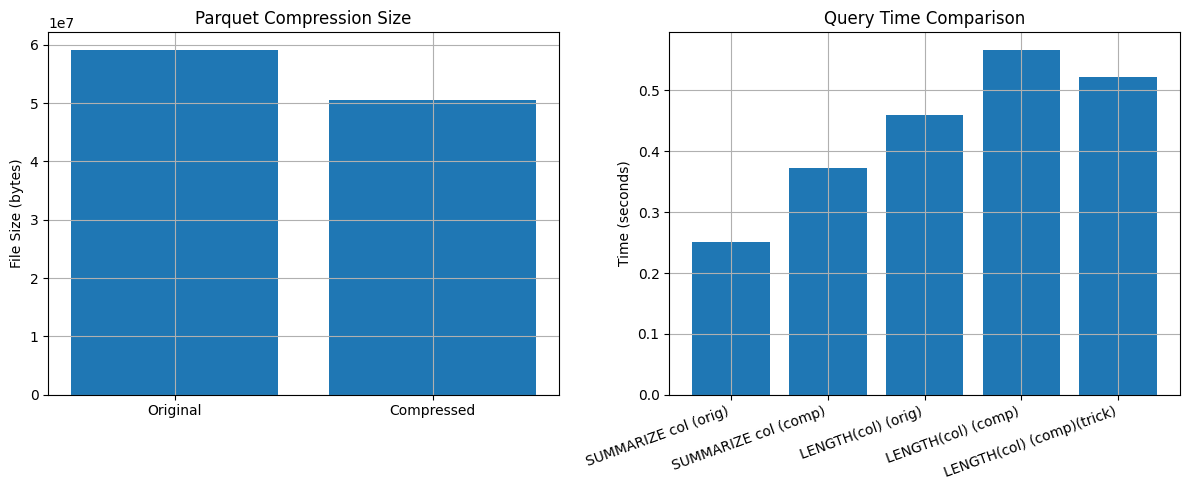

In [6]:
query_times = {
    "SUMMARIZE col (orig)": t1,
    "SUMMARIZE col (comp)": t2,
    "LENGTH(col) (orig)": t3,
    "LENGTH(col) (comp)": t4,
    "LENGTH(col) (comp)(trick)": t5
}
plot_results(original_size, compressed_size, query_times, "Fineweb URLs 2")

In [6]:
compressed_size / original_size

0.8536014137811012